## Exploratory & Unsupervised Analysis

In this file, we are going to visualize and preprocess the data. First of all, we load the raw_data.xslx.

In [ ]:
import pandas as pd
df = pd.read_excel('raw_data.xlsx')
display(df.head())

,Player,Rating 3.0,Kills per round,Kills per round win,Damage per round,Damage per round win,Rounds with a kill,Rounds with a multi-kill,Saved by teammate per round,Traded deaths per round,...,Sniper kills per round,Sniper kills percentage,Rounds with sniper kills percentage,Sniper multi-kill rounds,Sniper opening kills per round,Utility damage per round,Utility kills per 100 rounds,Flashes thrown per round,Flash assists per round,Time opponent flashed per round
0,donk,1.38,0.92,1.25,96.2,125.4,0.560,0.251,0.11,0.15,...,0.01,0.015,0.009,0.004,0.003,3.53,0.44,0.45,0.01,1.92
1,ZywOo,1.34,0.85,1.10,87.5,110.8,0.540,0.227,0.10,0.12,...,0.29,0.337,0.215,0.080,0.070,4.29,1.04,0.62,0.06,2.37
2,m0NESY,1.26,0.81,1.08,81.7,105.3,0.526,0.211,0.09,0.12,...,0.37,0.457,0.270,0.100,0.090,3.29,0.69,0.70,0.08,2.36
3,Luken,1.24,0.81,1.10,85.8,110.1,0.517,0.210,0.11,0.13,...,0.01,0.011,0.006,0.001,0.002,3.94,0.83,0.50,0.03,2.24
4,Frip,1.23,0.80,1.14,90.2,120.2,0.517,0.213,0.12,0.15,...,0.04,0.045,0.029,0.006,0.010,4.49,0.76,0.46,0.03,2.23


## Data Visualization

Now we do data visualization. The followings are the tasks that we are going to do:

1. Show the distribution of each feature.

2. Show the relationships with the target.

3. Use a correlation matrix to show relationships between features.


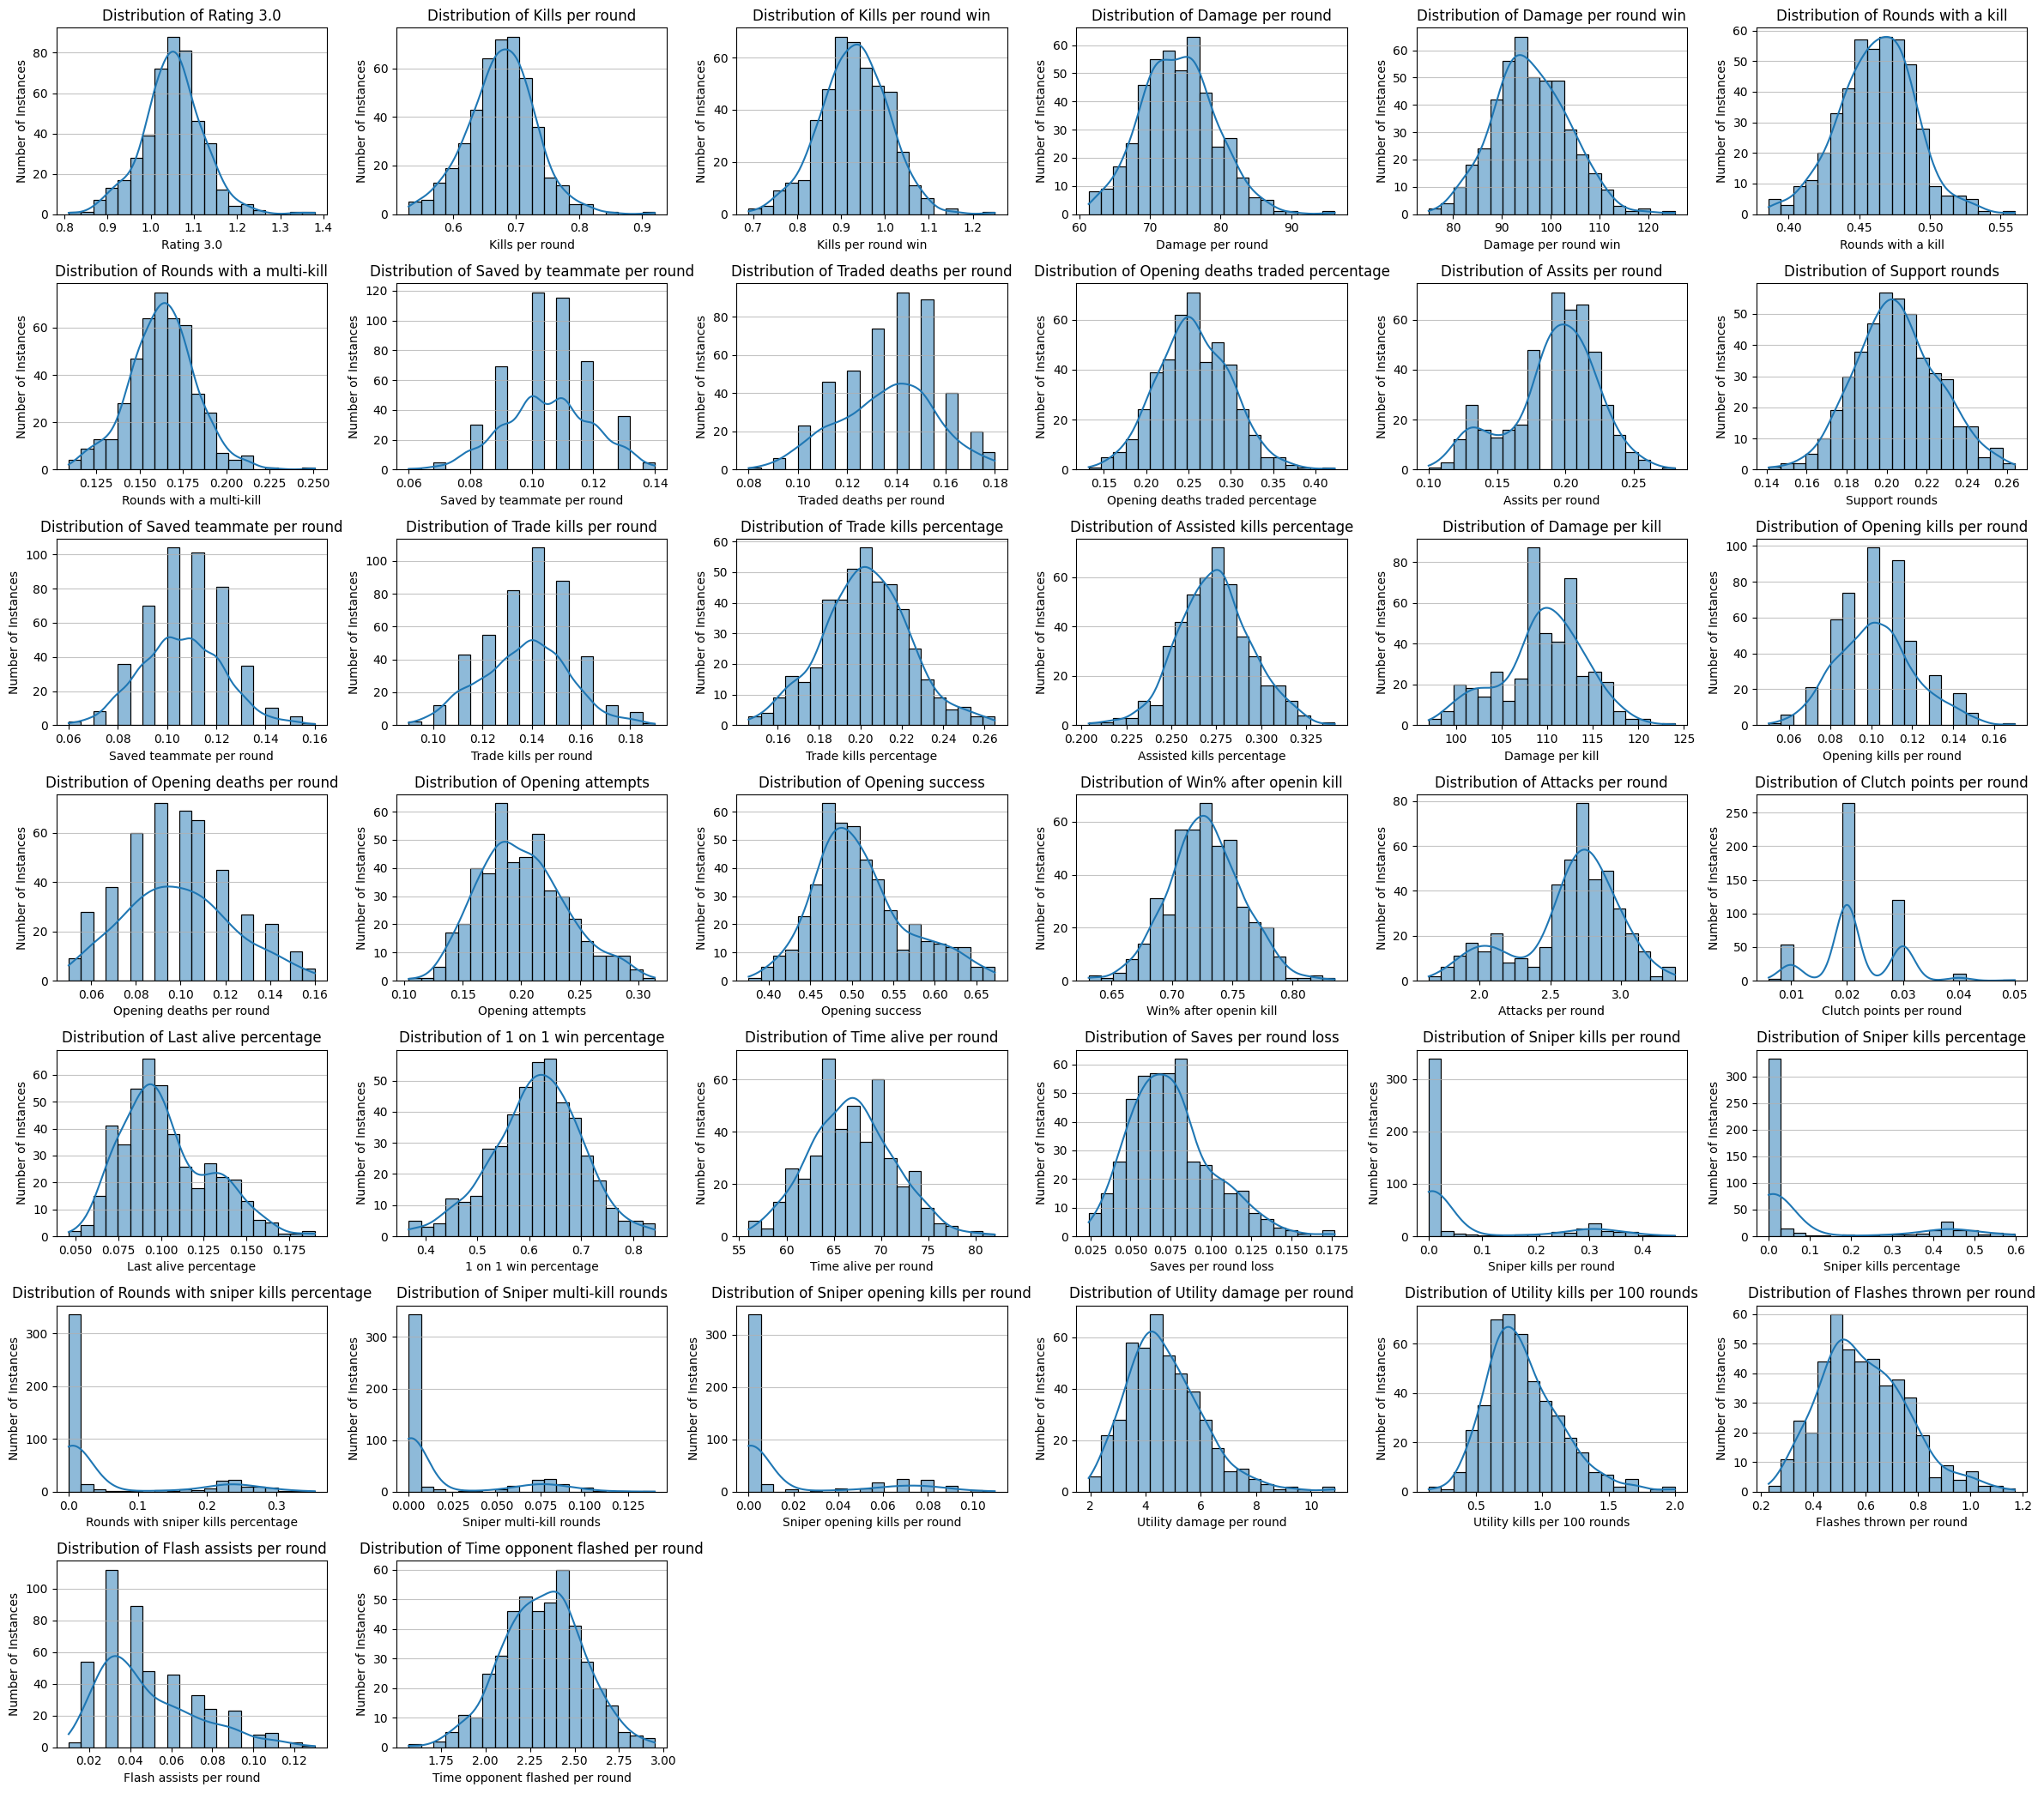

In [ ]:
# Distribution of each feature
import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_cols = df.select_dtypes(include=['number']).columns
n_cols = 6
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Number of Instances')
    axes[i].grid(axis='y', alpha=0.75)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

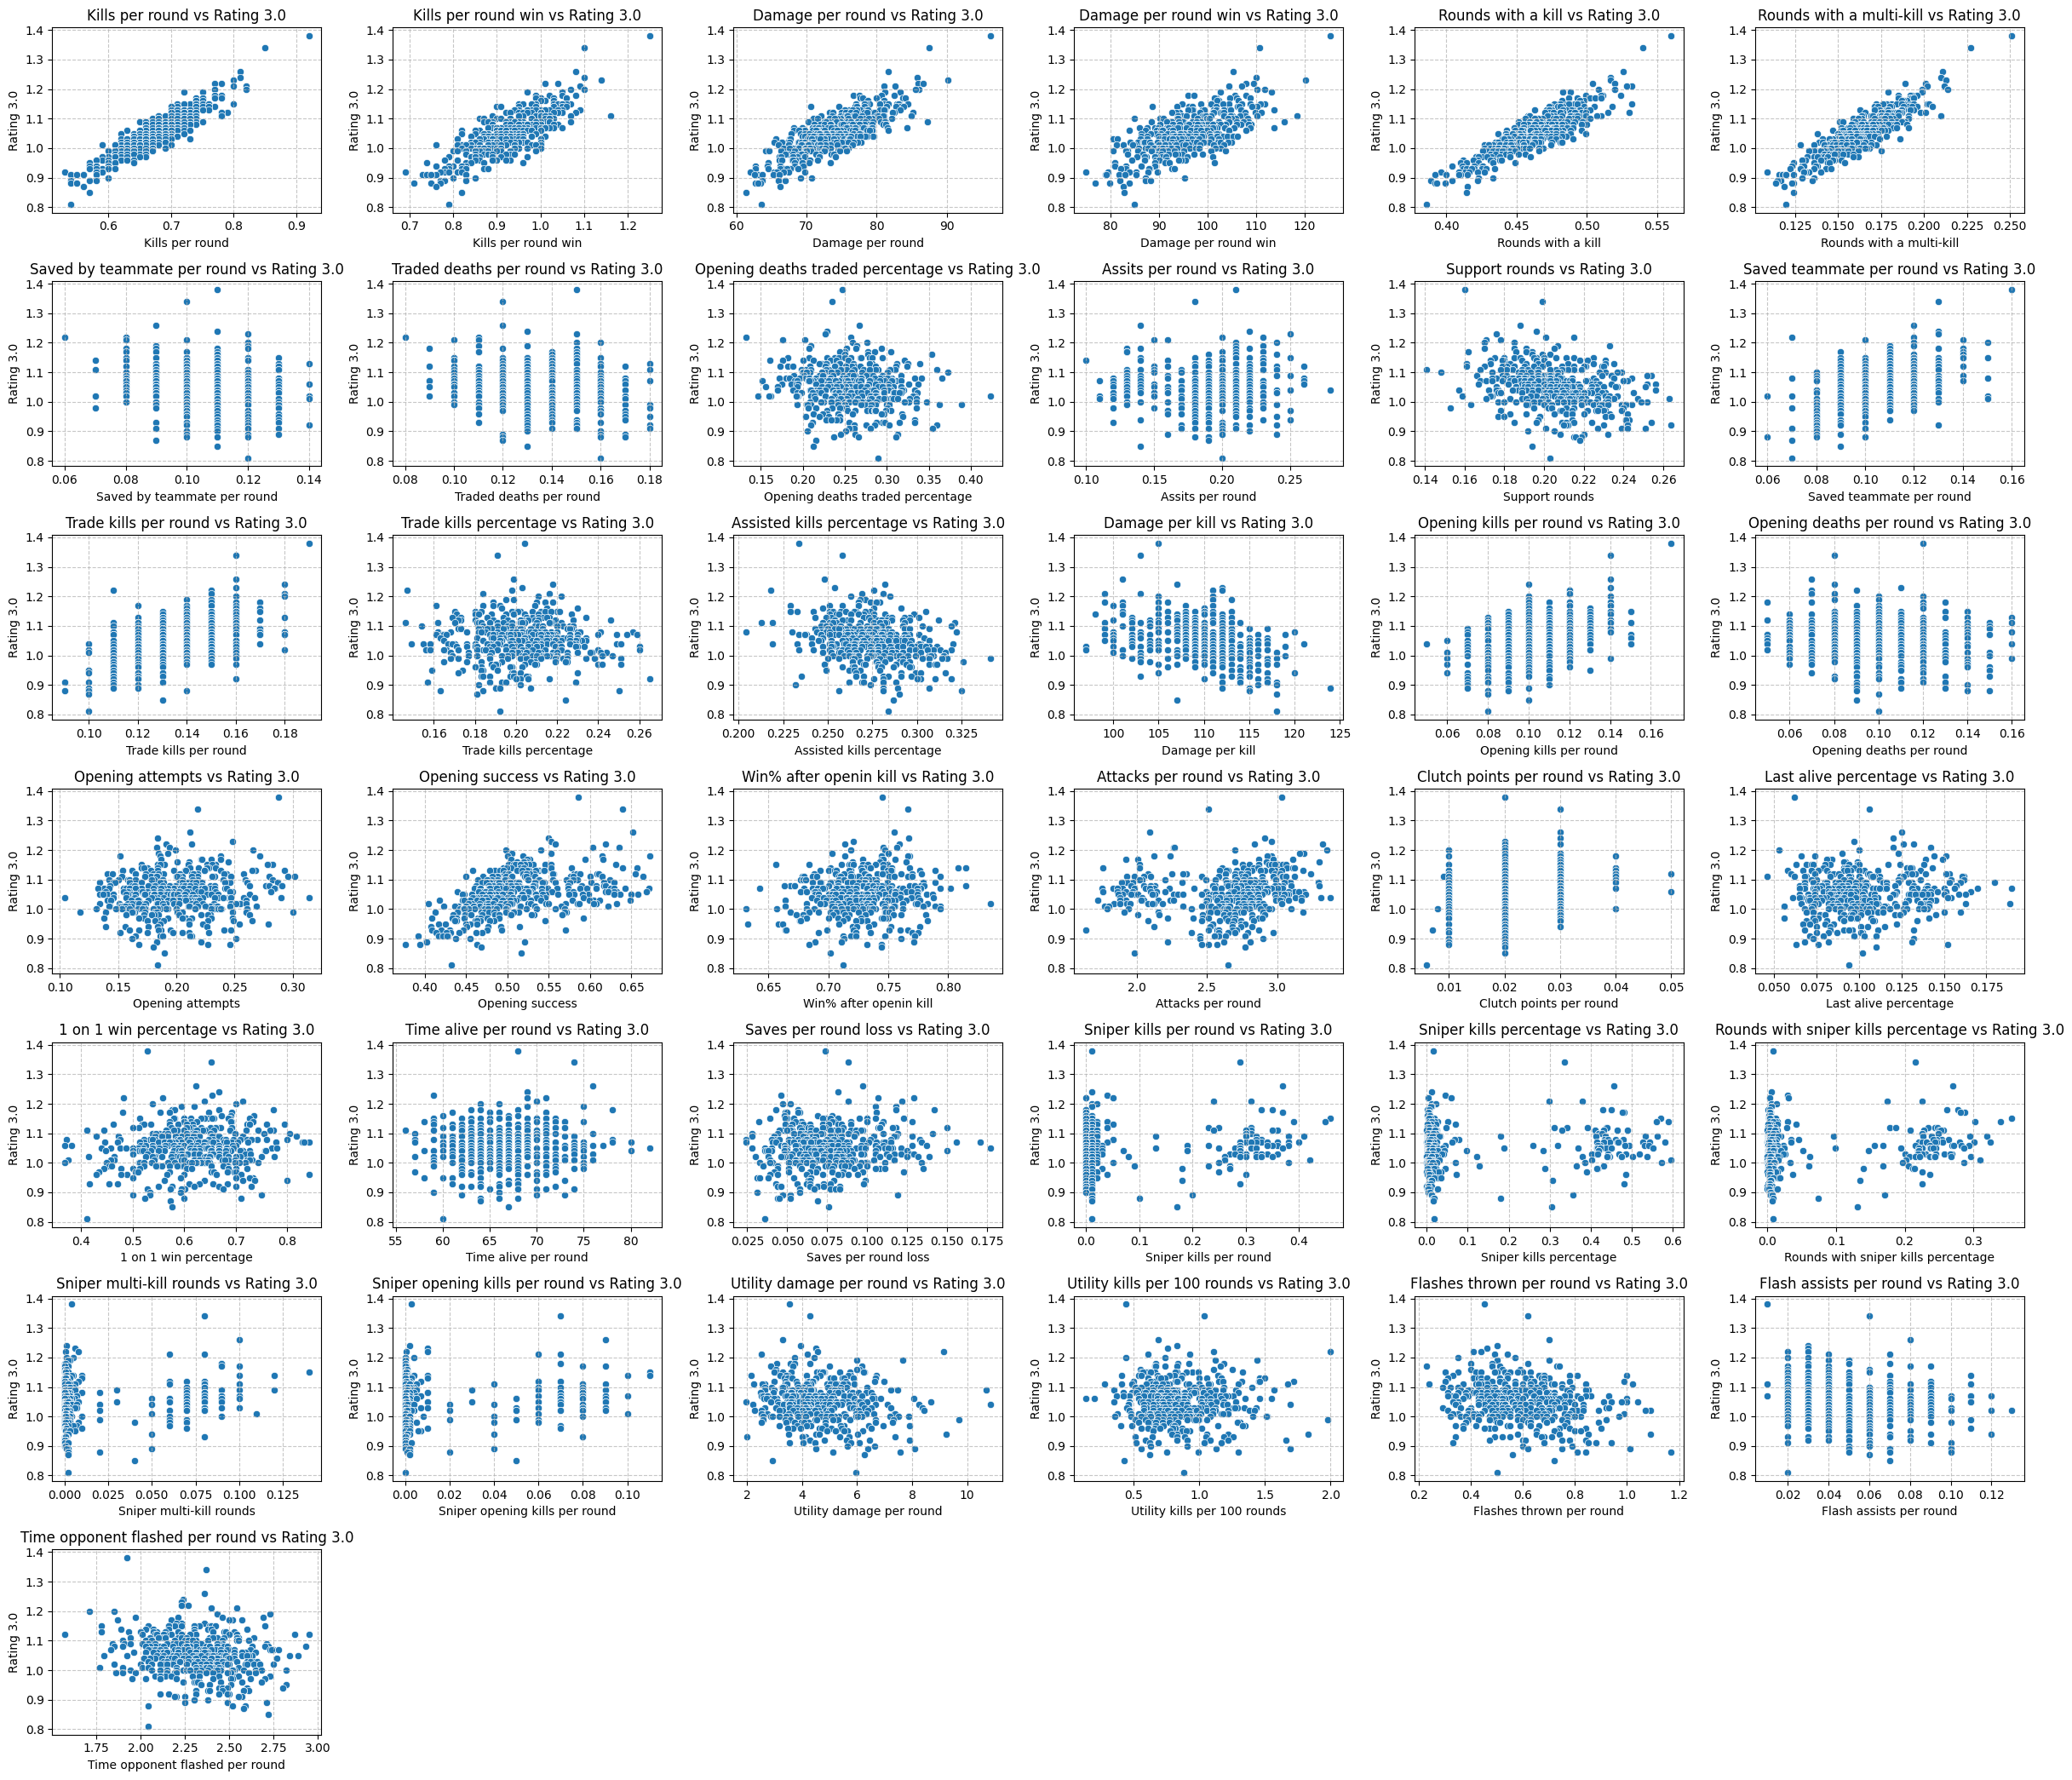

In [ ]:
# Relationships with the target
target_col = 'Rating 3.0'
numeric_features = [col for col in df.select_dtypes(include=['number']).columns if col != target_col]

n_cols = 6
n_rows = math.ceil(len(numeric_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.scatterplot(x=df[col], y=df[target_col], ax=axes[i])
    axes[i].set_title(f'{col} vs {target_col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_col)
    axes[i].grid(True, linestyle='--', alpha=0.7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

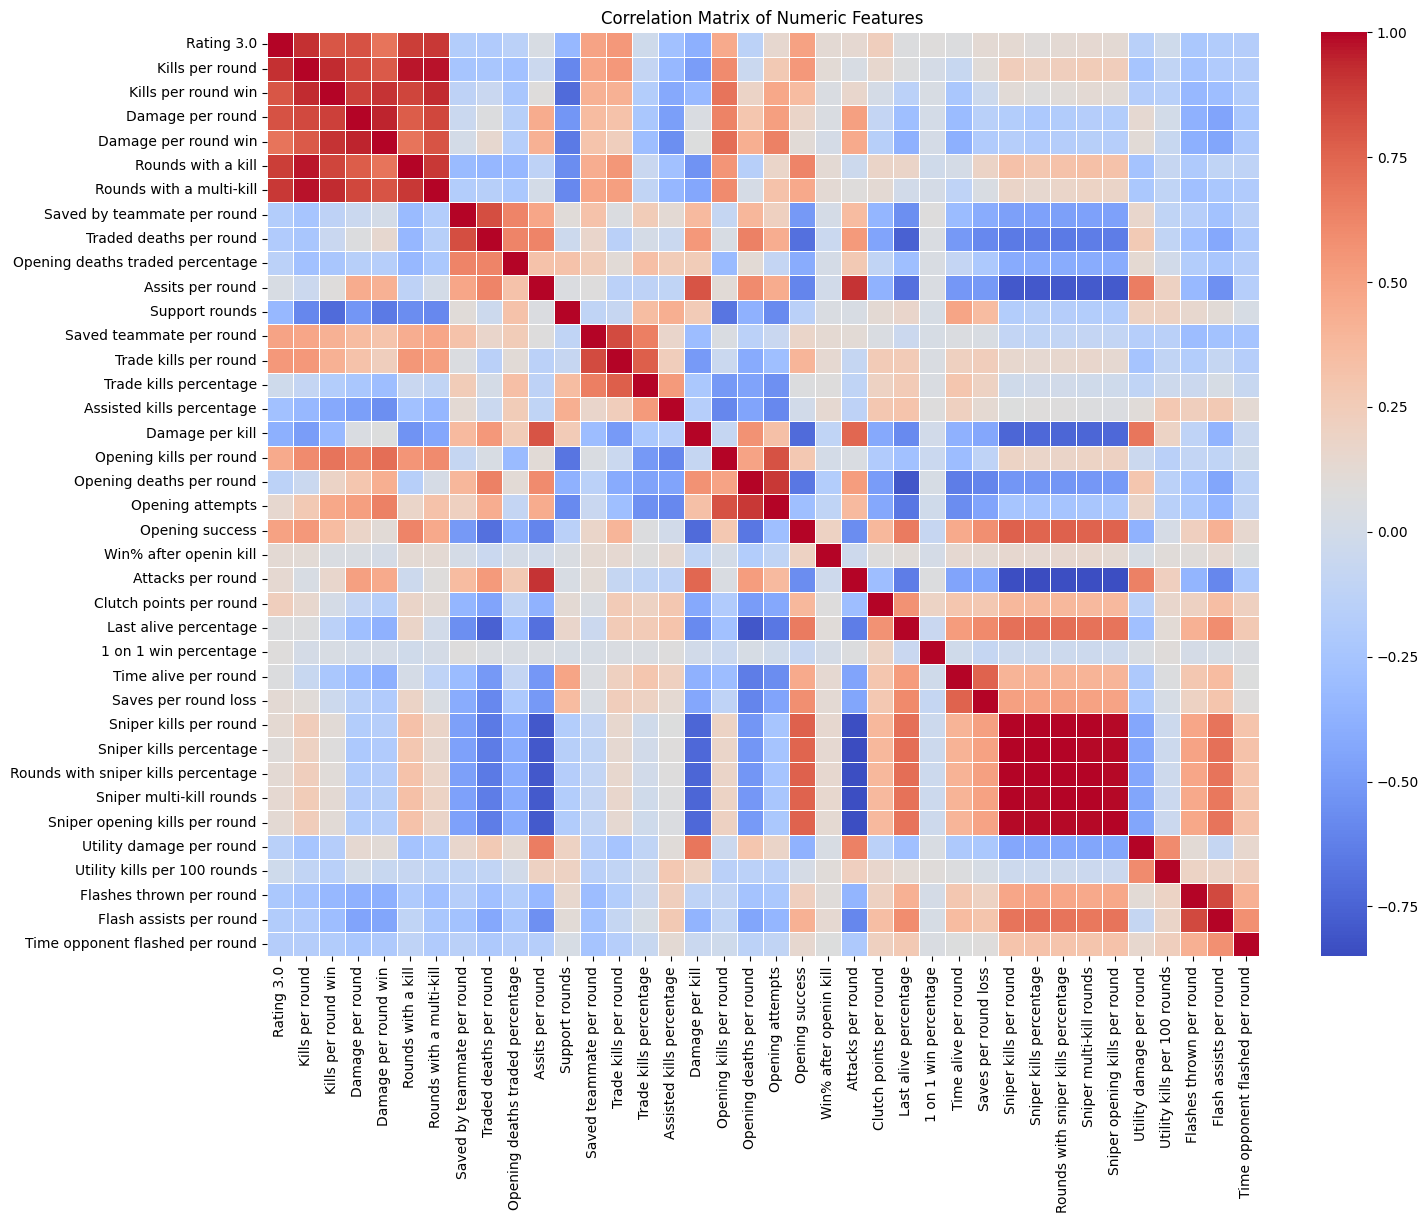

In [ ]:
# correlation matrix
plt.figure(figsize=(16, 12))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

## Data Preprocessing: Z-score Normalization

We apply z-score normalization on the raw_data so as to get preprocessed_data. We would also visualize the data after normalization.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create a copy of the original DataFrame for preprocessing
df_preprocessed = df.copy()

# Identify numeric features to normalize (excluding 'Rating 3.0')
numeric_features_to_normalize = [col for col in df.select_dtypes(include=['number']).columns if col != 'Rating 3.0']

scaler = StandardScaler()
df_preprocessed[numeric_features_to_normalize] = scaler.fit_transform(df_preprocessed[numeric_features_to_normalize])

print("Data normalized successfully for features:")
print(numeric_features_to_normalize)

display(df_preprocessed.head())

Data normalized successfully for features:
['Kills per round', 'Kills per round win', 'Damage per round', 'Damage per round win', 'Rounds with a kill', 'Rounds with a multi-kill', 'Saved by teammate per round', 'Traded deaths per round', 'Opening deaths traded percentage', 'Assits per round', 'Support rounds', 'Saved teammate per round', 'Trade kills per round', 'Trade kills percentage', 'Assisted kills percentage', 'Damage per kill', 'Opening kills per round', 'Opening deaths per round', 'Opening attempts', 'Opening success', 'Win% after openin kill', 'Attacks per round', 'Clutch points per round', 'Last alive percentage', '1 on 1 win percentage', 'Time alive per round', 'Saves per round loss', 'Sniper kills per round', 'Sniper kills percentage', 'Rounds with sniper kills percentage', 'Sniper multi-kill rounds', 'Sniper opening kills per round', 'Utility damage per round', 'Utility kills per 100 rounds', 'Flashes thrown per round', 'Flash assists per round', 'Time opponent flashed per

,Player,Rating 3.0,Kills per round,Kills per round win,Damage per round,Damage per round win,Rounds with a kill,Rounds with a multi-kill,Saved by teammate per round,Traded deaths per round,...,Sniper kills per round,Sniper kills percentage,Rounds with sniper kills percentage,Sniper multi-kill rounds,Sniper opening kills per round,Utility damage per round,Utility kills per 100 rounds,Flashes thrown per round,Flash assists per round,Time opponent flashed per round
0,donk,1.38,4.496020,4.144459,4.251909,3.834787,3.644449,4.552464,0.326134,0.709361,...,-0.482528,-0.487194,-0.477251,-0.422801,-0.436333,-0.847340,-1.479030,-0.870158,-1.603766,-1.789788
1,ZywOo,1.34,3.200176,2.206957,2.583746,1.931851,2.896591,3.308668,-0.370746,-0.815990,...,1.768442,1.334941,1.675290,1.977071,1.850832,-0.301064,0.655636,0.158405,0.503270,0.218072
2,m0NESY,1.26,2.459693,1.948623,1.471637,1.214992,2.373089,2.479470,-1.067627,-0.815990,...,2.411577,2.013997,2.249998,2.608616,2.533568,-1.019848,-0.589586,0.642434,1.346084,0.173453
3,Luken,1.24,2.459693,2.206957,2.257783,1.840615,2.036553,2.427645,0.326134,-0.307540,...,-0.482528,-0.509830,-0.508598,-0.517532,-0.470470,-0.552638,-0.091497,-0.567640,-0.760952,-0.361976
4,Frip,1.23,2.274573,2.723624,3.101452,3.157029,2.036553,2.583120,1.023014,0.709361,...,-0.241353,-0.317430,-0.268266,-0.359646,-0.197375,-0.157307,-0.340541,-0.809654,-0.760952,-0.406595


In [ ]:
# Save the preprocessed DataFrame to a new Excel file
output_filename = 'preprocessed_data.xlsx'
df_preprocessed.to_excel(output_filename, index=False)

print(f"Preprocessed data saved to '{output_filename}'")

Preprocessed data saved to 'preprocessed_data.xlsx'


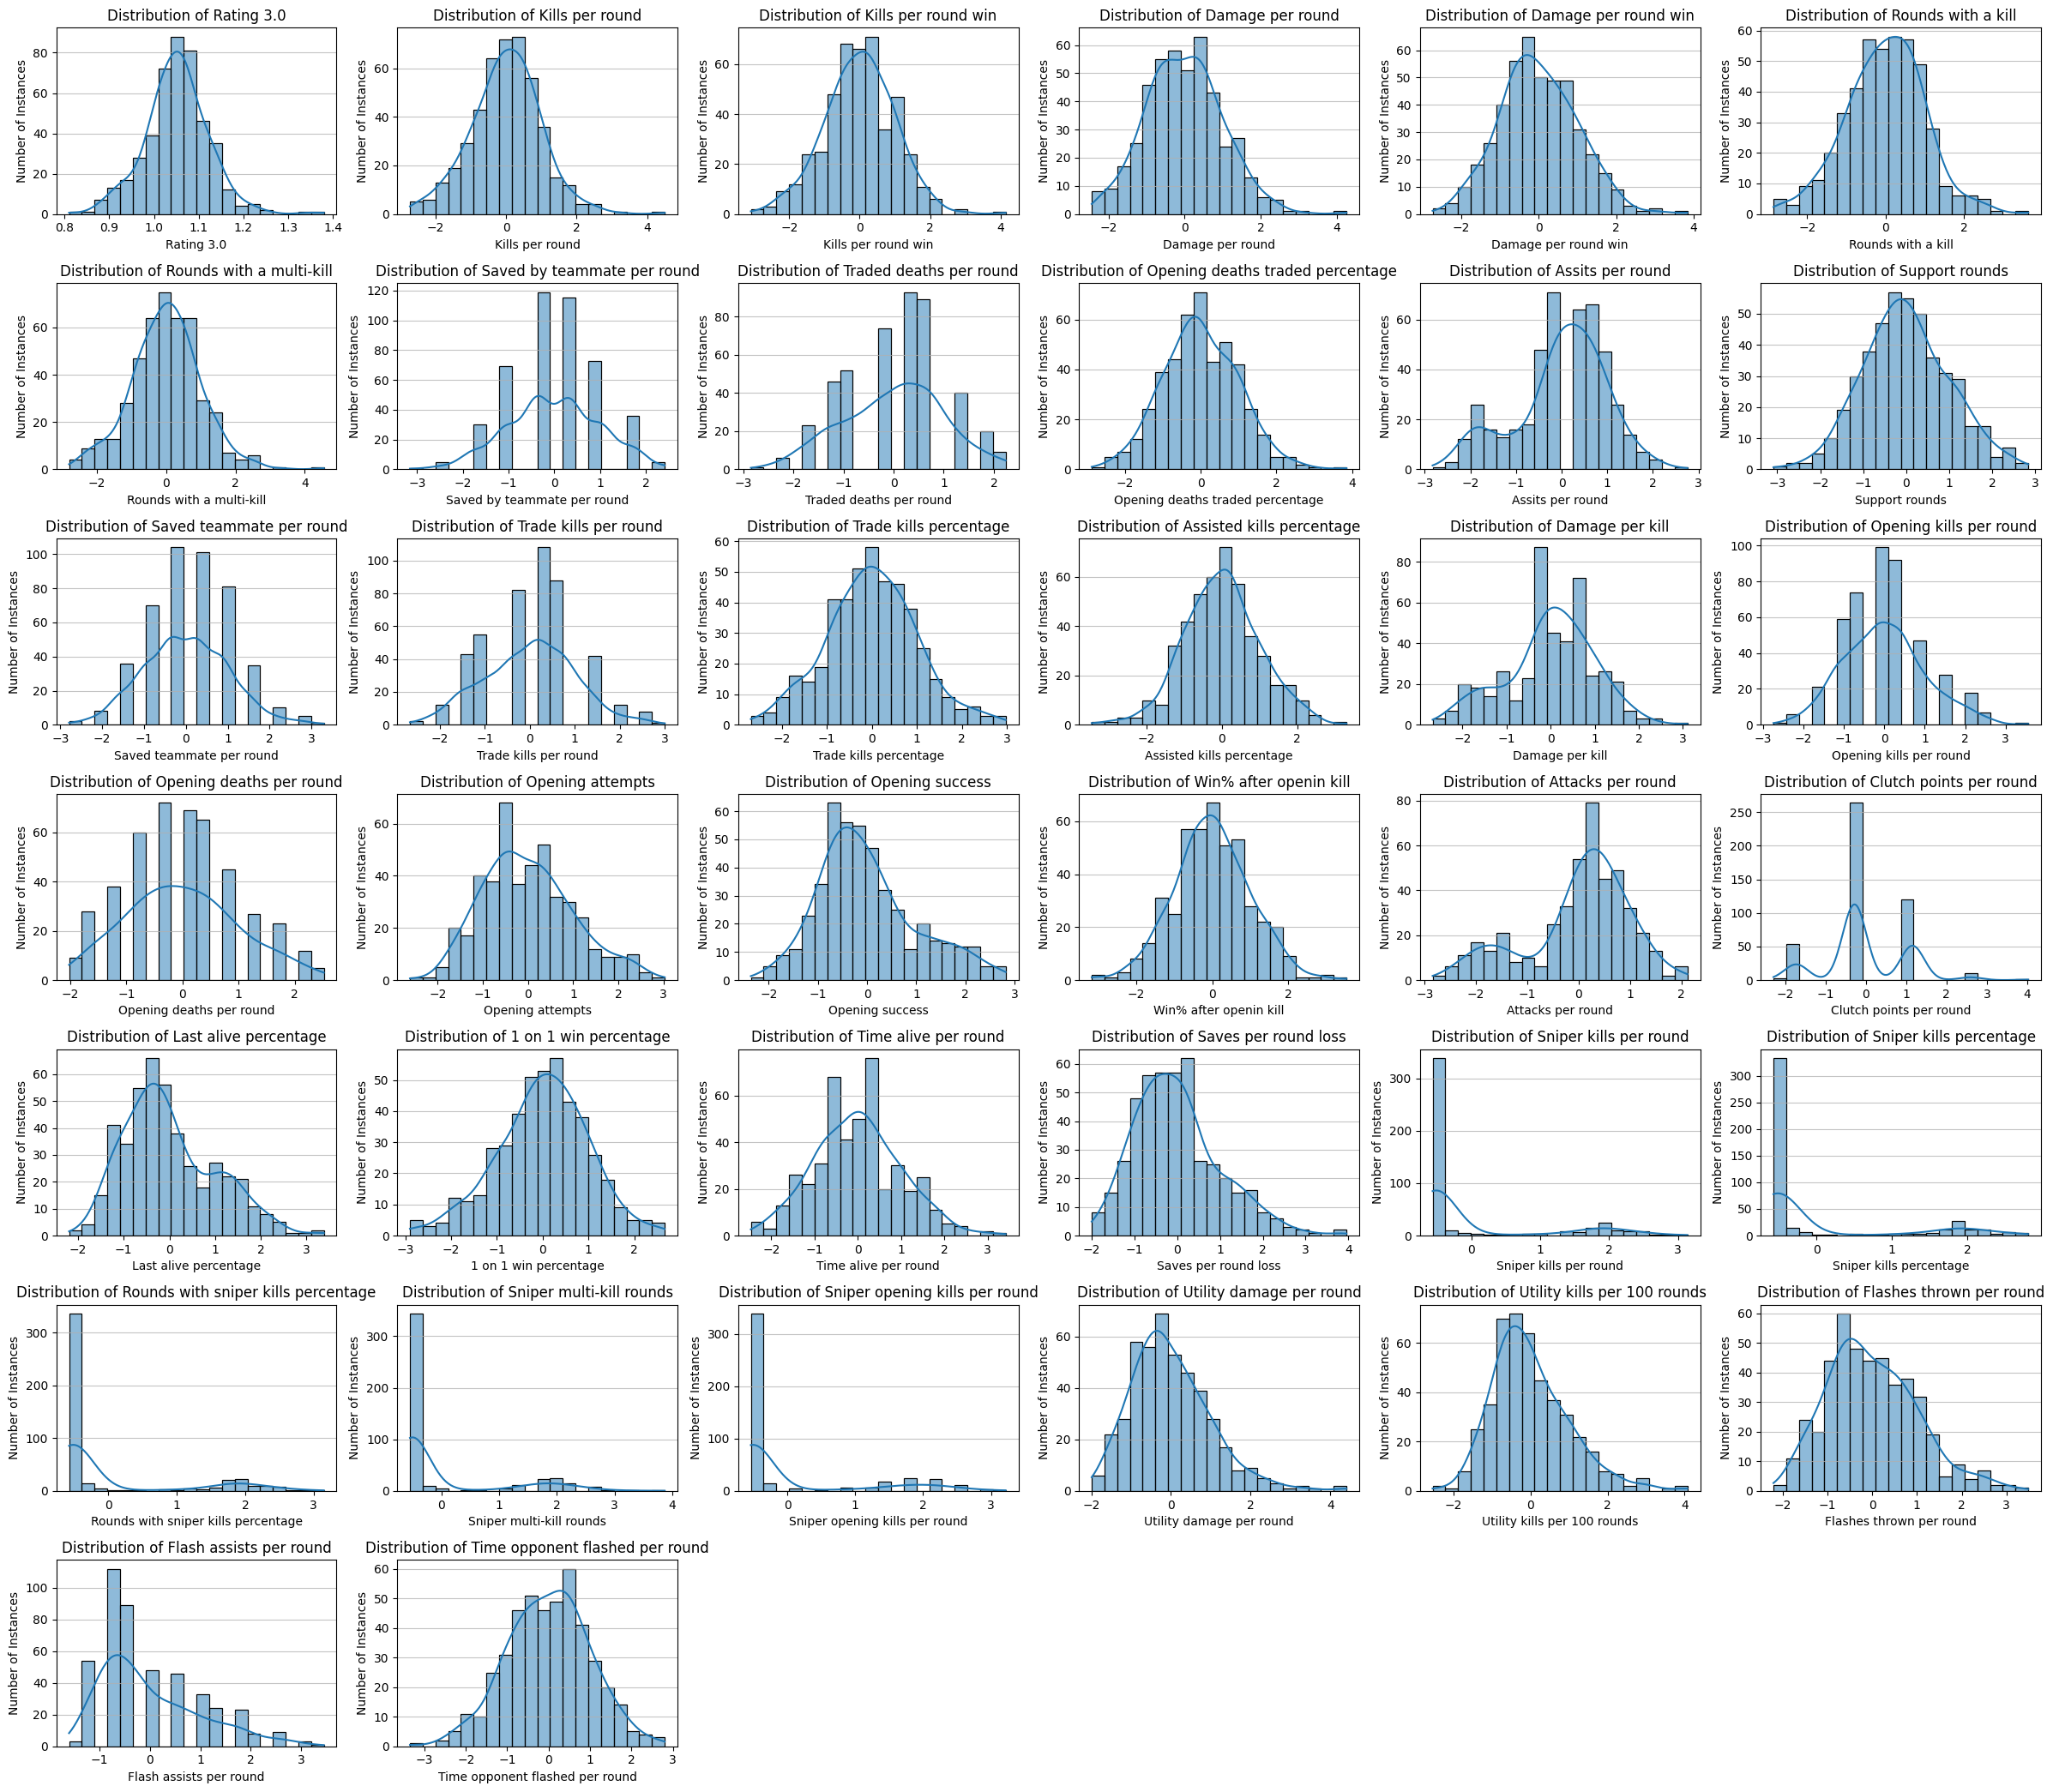

In [ ]:
# Distribution of each normalized feature
import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_cols_preprocessed = df_preprocessed.select_dtypes(include=['number']).columns
n_cols = 6
n_rows = math.ceil(len(numeric_cols_preprocessed) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_preprocessed):
    sns.histplot(df_preprocessed[col], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Number of Instances')
    axes[i].grid(axis='y', alpha=0.75)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()